In [1]:
from IPython.display import Image, display, SVG, HTML

from typing import Dict, List, Tuple

import scipy
from math import ceil
from scipy.stats import pearsonr, spearmanr, kendalltau
from scipy.signal import correlate, medfilt
from interval_timeline import CallGraph
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re

import otf2
import hatchet as ht
import thicket as tt

In [2]:
# IDLE_PERIODS_MS = [50, 100, 200, 300, 400, 500]
# ACTIVE_PERIODS_MS = [50, 100, 200, 300, 400, 500]
# IDLE_PERIODS_MS = [1, 5, 20, 50, 100, 200, 400, 600]
# ACTIVE_PERIODS_MS = [1, 5, 20, 50, 100, 200, 400, 600]
# ACTIVE_VALUES=(1 5 20 30 50 75 100 150 200 400 600 800 1000)
ACTIVE_PERIODS_MS = [1, 5, 20, 30, 50, 75, 100, 150, 200, 400, 600, 800, 1000]
IDLE_PERIODS_MS = [1, 5, 20, 30, 50, 75, 100, 150, 200, 400, 600, 800, 1000]
# IDLE_PERIODS_MS = [5]
# ACTIVE_PERIODS_MS = [500]
# IDLE_PERIODS_MS = [500]
# ACTIVE_PERIODS_MS = [5]
def get_run_trace_path(idle_period_ms: int, active_period_ms: int) -> str:
    """Get the path to the run trace file based on idle and active periods."""
    return f"scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-{idle_period_ms}ms-{active_period_ms}ms/traces.otf2"

# IDLE_PERIODS_MS = [400]
# ACTIVE_PERIODS_MS = [800]
# IDLE_PERIODS_MS = [100, 200, 400, 600, 800]
# ACTIVE_PERIODS_MS = [100, 200, 400, 600, 800]
# def get_run_trace_path(idle_period_ms: int, active_period_ms: int) -> str:
#     """Get the path to the run trace file based on idle and active periods."""
#     return f"scorep-traces/idle-compute-step-2/idle-compute-step-{idle_period_ms}ms-{active_period_ms}ms/traces.otf2"

In [3]:
# TRACE_DIR = "./scorep-traces/mi300-multiple-kernels-two-gpus/traces.otf2"
PROCESSES_TO_TRACK = [
    'Process',
    # 'MPI Rank 0',
]
METRICS_TO_TRACK = [
    'A2rocm_smi:::energy_count:device=0',
    'A2rocm_smi:::energy_count:device=2',
    'A2rocm_smi:::energy_count:device=4',
    'A2rocm_smi:::energy_count:device=6',
    
    'A2coretemp:::craypm:accel0_energy',
    'A2coretemp:::craypm:accel1_energy',
    'A2coretemp:::craypm:accel2_energy',
    'A2coretemp:::craypm:accel3_energy',
    
    'A3coretemp:::craypm:accel0_energy',
    'A3coretemp:::craypm:accel1_energy',
    'A3coretemp:::craypm:accel2_energy',
    'A3coretemp:::craypm:accel3_energy',
    
    'A2coretemp:::craypm:accel0_power',
    'A2coretemp:::craypm:accel1_power',
    'A2coretemp:::craypm:accel2_power',
    'A2coretemp:::craypm:accel3_power',

    'A3coretemp:::craypm:accel0_power',
    'A3coretemp:::craypm:accel1_power',
    'A3coretemp:::craypm:accel2_power',
    'A3coretemp:::craypm:accel3_power',
]

def callgraph_to_csv(call_graph: CallGraph, group: str, thread: str, filename: str):
    """Convert a CallGraph to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Thread,Group,Depth,Name,Start Time,End Time,Duration\n")
        intervals = call_graph.get_intervals_between(0, float('inf'))
        
        for interval in intervals:
            start = interval.start
            end = interval.end or float('inf')
            duration = end - start
            name = interval.name if interval.name else "Unknown"
            depth = interval.depth if interval.depth else 0

            f.write(f"{thread},{group},{depth},\"{name}\",{start},{end},{duration}\n")

def metrics_to_csv(group: str, thread_metrics: Dict[str, List[Tuple[float, float]]], filename: str):
    """Convert metrics to a CSV file."""
    with open(filename, 'w') as f:
        f.write("Group,Metric Name,Time,Value\n")
        for metric_name, values in thread_metrics.items():
            for time, value in values:
                f.write(f"{group},{metric_name},{time},{value}\n")

def read_metrics_dataframe(file: str) -> pd.DataFrame:
    df = pd.read_csv(file)
    # For all the rocm metrics, divide by 1e6 to convert from uJ to J
    for metric_name in df['Metric Name'].unique():
        if 'rocm_smi:::energy_count:device' in metric_name:
            df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000
    return df

def read_call_graph_dataframe(file: str) -> pd.DataFrame:
    return pd.read_csv(file)


In [4]:
# Remove all the old CSV files
for file in os.listdir('.'):
    if file.endswith('.csv'):
        os.remove(file)

In [5]:
def trace_to_csv(trace: str, processes_to_track: List[str], metrics_to_track: List[str]):
    call_graphs = {}
    metrics = {}

    start_time = None
    timer_resolution = None

    seen: Dict[str, set[str]] = {}

    def timestamp_to_seconds(timestamp):
        """Convert a timestamp in nanoseconds to seconds."""
        if timestamp is None or start_time is None or timer_resolution is None:
            return 0.0
        return (timestamp - start_time) / timer_resolution

    with otf2.reader.open(trace) as reader:
        defs = reader.definitions
        timer_resolution = reader.timer_resolution
        print(f"Timer resolution: {timer_resolution} ticks per second ({timer_resolution / 1e9} per nanosecond)")
        print(f"Number of metric members: {len(defs.metric_members)}")
        print(f'Definitions: {defs}')
        count = 0
        for location, event in reader.events:
            count += 1
            # thread = (location.name, location.group.name)
            group = location.group.name
            if location.group.creating_location_group is not None:
                group = location.group.creating_location_group.name
            thread = location.name
            
            if group not in seen:
                seen[group] = set()
            if thread not in seen[group]:
                seen[group].add(thread)
                print(f"New thread: {thread} in group {group}")
            if group not in call_graphs:
                call_graphs[group] = {thread: CallGraph()}
            if thread not in call_graphs[group]:
                call_graphs[group][thread] = CallGraph()
            if group not in metrics:
                metrics[group] = {metric: [] for metric in METRICS_TO_TRACK}
            
            if isinstance(event, otf2.events.ProgramBegin):
                start_time = event.time
                continue
            elif isinstance(event, otf2.events.ProgramEnd):
                end_time = event.time
                continue
            
            current_time = timestamp_to_seconds(event.time)
            
            if isinstance(event, otf2.events.Metric):
                metric_name = event.member.name
                if group not in metrics:
                    continue
                if metric_name not in metrics[group]:
                    continue
                if 'cray' in metric_name:
                    current_time -= 0.16  # Adjust for craypm metrics, as they are reported with a delay
                
                if len(metrics[group][metric_name]) == 0 or metrics[group][metric_name][-1][1] != event.value:
                    metrics[group][metric_name].append((current_time, event.value))
                
            if group not in processes_to_track:
                continue
            
            if isinstance(event, otf2.events.Enter):
                call_graphs[group][thread].enter(current_time, name=event.region.name)
            elif isinstance(event, otf2.events.Leave):
                try:
                    call_graphs[group][thread].leave(current_time)
                except Exception as e:
                    print(f"Error leaving call graph for {group} {thread}: {e}")
                    continue
        print(f"Processed {count} events.")
        
    for group, threads in call_graphs.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        for thread, call_graph in threads.items():
            filename = f"{group}_{thread.replace(' ', '_')}_callgraph.csv"
            print(f'Writing to file: {filename}')
            callgraph_to_csv(call_graph, group, thread, filename)

    for group, thread_metrics in metrics.items():
        if group not in processes_to_track:
            print(f"Skipping group {group} as it is not in the processes to track.")
            continue
        filename = f"{group}_metrics.csv"
        print(f'Writing to file: {filename}')
        metrics_to_csv(group, thread_metrics, filename)
    
# Visualize the dataframes
def visualize_dataframe(df):
    """Visualize the first few rows of a DataFrame as HTML."""
    # pd.set_option("display.width", 2400)
    # pd.set_option("display.max_colwidth", 100)
    # pd.set_option("display.max_rows", 20)
    
    display(HTML(df.head(n=20).to_html(index=False)))

# trace_to_csv(TRACE_DIR, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
# visualize_dataframe(read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv"))
# visualize_dataframe(read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv"))

In [6]:
def sampled_to_continuous(df, time_col='Time', value_col='Value'):
    t_samples = df[time_col].astype(float)
    y = df[value_col].astype(float)
    # # Get the average time between samples
    # time_between_samples = np.mean(np.diff(t_samples))
    # # Now, how many samples are there in 0.4 seconds?
    # period = 0.4  # seconds
    # print(f"Average time between samples: {time_between_samples} seconds")
    # print(f"Samples per period (0.4 seconds): {ceil(period / time_between_samples)}")
    # # Calculate the number of samples per period
    # samples_per_period = ceil(period / time_between_samples)    
    
    # # y = scipy.signal.savgol_filter(y, window_length=samples_per_period, polyorder=2, mode='nearest')
    # # Apply a median filter to smooth the data
    # y = medfilt(y, kernel_size=samples_per_period + samples_per_period % 2 + 1)
 
    # Create a continuous function that interpolates the sampled data
    f = lambda t: np.interp(t, t_samples, y)
    return f

def windowed_average(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the average of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the average over the window
        avg = np.array([np.mean(f(t + t_grid)) for t in x_arr])
        return avg.item() if np.isscalar(x) else avg
    
    return F

def windowed_median(f, window_period=0.1, sample_period=0.001):
    """
    Return a function F(x) that computes the median of f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Create a time grid for the window
        t_grid = np.arange(-window_period / 2, window_period / 2, sample_period)
        # Compute the median over the window
        med = np.array([np.median(f(t + t_grid)) for t in x_arr])
        return med.item() if np.isscalar(x) else med
    
    return F

def windowed_savgol(f, sample_period=0.1, polyorder=2):
    """
    Return a function F(x) that applies a Savitzky-Golay filter to f(t) over a window of size window_size.
    The function F(x) will return a scalar when x is a scalar, and an array when x is an array.
    """
    return lambda x: scipy.signal.savgol_filter(
        np.array([f(t) for t in np.atleast_1d(x).astype(float)]),
        window_length=ceil(1/sample_period),  # Convert window size to number of samples
        polyorder=polyorder,
        mode='nearest'
    )

def numerical_derivative(func, h=1e-5):
    """Compute the numerical derivative of a function at a point t."""
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

def numerical_integral(f, a=0.0, dx=1e-1):
    """
    Return a function F(x) that approximates the integral of f(t) dt from t=a to t=x,
    using the trapezoidal rule in a fully vectorized manner.
    The function F(x) will return a scalar when x is a scalar, and an array
    when x is an array.
    """
    # Determinar si f soporta arrays de NumPy
    try:
        _ = f(np.array([a, a + dx]))
        f_np = f
    except Exception:
        f_np = np.vectorize(f)
    
    def F(x):
        x_arr = np.atleast_1d(x).astype(float)
        # Manejo de x < a invirtiendo signo
        sign = np.ones_like(x_arr)
        mask = x_arr < a
        sign[mask] = -1
        x_pos = np.where(mask, a + (a - x_arr), x_arr)
        
        # Grid hasta el máximo de x
        xmax = x_pos.max()
        t = np.arange(a, xmax + dx, dx)
        u = f_np(t)
        
        # Suma acumulada de trapecios
        trap_heights = (u[:-1] + u[1:]) / 2
        cum = np.concatenate(([0], np.cumsum(trap_heights * dx)))
        
        # Índices y remanentes
        idx = ((x_pos - a) // dx).astype(int)
        rem = x_pos - (a + idx * dx)
        
        # Valores en fronteras
        f_end = f_np(x_pos)
        f_start = u[idx]
        
        # Integral aproximada
        integral = cum[idx] + (f_start + f_end) * rem / 2
        result = sign * integral
        
        # Devolver escalares cuando corresponda
        return result.item() if np.isscalar(x) else result
    
    return F


In [7]:
def load_trace(idle_period_ms: int, active_period_ms: int):
    """Load the trace for a specific idle and active period."""
    try:
        trace_path = get_run_trace_path(idle_period_ms, active_period_ms)
        if not os.path.exists(trace_path):
            raise FileNotFoundError(f"Trace file {trace_path} does not exist.")
        print(f"Loading trace from {trace_path} for idle period {idle_period_ms} ms and active period {active_period_ms} ms.")
        trace_to_csv(trace_path, PROCESSES_TO_TRACK, METRICS_TO_TRACK)
        # Load the CSV files into dataframes
        metrics_df = read_metrics_dataframe(f"{PROCESSES_TO_TRACK[0]}_metrics.csv")
        call_graph_df = read_call_graph_dataframe(f"{PROCESSES_TO_TRACK[0]}_Master_thread_callgraph.csv")
    except Exception as e:
        print(f"Error loading trace: {e}")
        metrics_df = pd.DataFrame(columns=['Group', 'Metric Name', 'Time', 'Value'])
        call_graph_df = pd.DataFrame(columns=['Thread', 'Group', 'Depth', 'Name', 'Start Time', 'End Time', 'Duration'])
    return metrics_df, call_graph_df

traces = {
    (idle_period_ms, active_period_ms): load_trace(idle_period_ms, active_period_ms)
    for idle_period_ms in IDLE_PERIODS_MS
    for active_period_ms in ACTIVE_PERIODS_MS
}


Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-1ms-1ms/traces.otf2 for idle period 1 ms and active period 1 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x12b0d1d30>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 1103322 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_23476/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.60852558e+08 2.60852559e+08 2.60852559e+08 ... 2.60863164e+08
 2.60863165e+08 2.60863165e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-1ms-5ms/traces.otf2 for idle period 1 ms and active period 5 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x12b1816d0>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 1139184 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_23476/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[6.63875827e+08 6.63875828e+08 6.63875828e+08 ... 6.63887198e+08
 6.63887198e+08 6.63887198e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-1ms-20ms/traces.otf2 for idle period 1 ms and active period 20 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x12b181590>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 1107812 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


...

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_23476/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.06332759e+08 2.06332760e+08 2.06332760e+08 ... 2.06340817e+08
 2.06340817e+08 2.06340818e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-1000ms-800ms/traces.otf2 for idle period 1000 ms and active period 800 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x13bdefed0>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 821880 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_23476/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[6.52511258e+08 6.52511258e+08 6.52511259e+08 ... 6.52519924e+08
 6.52519924e+08 6.52519925e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


Loading trace from scorep-traces/idle-compute-step-8-freq-and-capped/idle-compute-step-1000ms-1000ms/traces.otf2 for idle period 1000 ms and active period 1000 ms.
Timer resolution: 1000000000 ticks per second (1.0 per nanosecond)
Number of metric members: 13
Definitions: <otf2.registry.DefinitionRegistry object at 0x13bdef250>
New thread: Master thread in group Process
New thread:  in group Process
New thread: Per process metrics in group Process
New thread: HIP[0:0] in group Process
Processed 834940 events.
Writing to file: Process_Master_thread_callgraph.csv
Writing to file: Process__callgraph.csv
Writing to file: Process_Per_process_metrics_callgraph.csv
Writing to file: Process_HIP[0:0]_callgraph.csv
Writing to file: Process_metrics.csv


/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_23476/4093504985.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[6.52521509e+08 6.52521509e+08 6.52521509e+08 ... 6.52530384e+08
 6.52530384e+08 6.52530385e+08]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Metric Name'] == metric_name, 'Value'] /= 1_000_000


In [8]:
# print(traces[(50, 50)][0])
# Convert to CSV
# df = traces[(5, 5)][0]
run = list(traces.keys())[0]  # Example run, can be changed
df = traces[run][0]
df.to_csv('metrics.csv', index=False)

In [9]:
# Convert each trace to a continuous function for the first GPU energy
gpu_energies_continuous = {
    (idle_period_ms, active_period_ms): {
        metric_name: sampled_to_continuous(trace[0][trace[0]['Metric Name'] == metric_name]) if 'energy' in metric_name else numerical_integral(sampled_to_continuous(trace[0][trace[0]['Metric Name'] == metric_name]))
        for metric_name in METRICS_TO_TRACK if metric_name in trace[0]['Metric Name'].values
    }
    for (idle_period_ms, active_period_ms), trace in traces.items()
}
print(gpu_energies_continuous)

{(1, 1): {'A2rocm_smi:::energy_count:device=0': <function sampled_to_continuous.<locals>.<lambda> at 0x105d84400>, 'A2rocm_smi:::energy_count:device=2': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8d080>, 'A2rocm_smi:::energy_count:device=4': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8c9a0>, 'A2rocm_smi:::energy_count:device=6': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8f240>, 'A2coretemp:::craypm:accel0_energy': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8ca40>, 'A2coretemp:::craypm:accel1_energy': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8ec00>, 'A2coretemp:::craypm:accel2_energy': <function sampled_to_continuous.<locals>.<lambda> at 0x13bde2f20>, 'A2coretemp:::craypm:accel3_energy': <function sampled_to_continuous.<locals>.<lambda> at 0x13bde2ca0>, 'A2coretemp:::craypm:accel0_power': <function numerical_integral.<locals>.F at 0x13bde2ac0>, 'A2coretemp:::craypm:accel1_power': <function numerical_integ

Plotting GPU energies for run (1, 1)


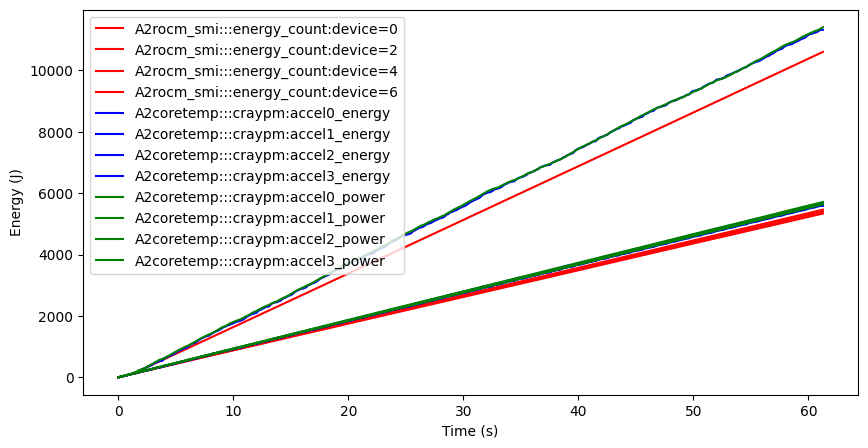

In [10]:
# Graph all the metrics for the specific run
run = list(traces.keys())[0]  # Example run, can be changed
plt.figure(figsize=(10, 5))
for metric_name, func in gpu_energies_continuous[run].items():
    # Get the max time sample from the traces
    max_time = traces[run][0]['Time'].max()
    t = np.arange(0, max_time, 0.01)  # Time vector for plotting
    y = func(t) - func(0)  # Evaluate the function at the time points

    if 'rocm' in metric_name:
        # Color red
        plt.plot(t, y, label=metric_name, color='red')
    elif 'craypm' in metric_name and 'energy' in metric_name:
        # Color blue
        plt.plot(t, y, label=metric_name, color='blue')
    elif 'craypm' in metric_name and 'power' in metric_name:
        # Color green
        plt.plot(t, y, label=metric_name, color='green')
    
plt.legend()
print(f"Plotting GPU energies for run {run}")
plt.ylabel('Energy (J)')    
plt.xlabel('Time (s)')
plt.show()

In [11]:
# Convert each trace to a continuous function for the first GPU energy
gpu_powers_continuous = {
    (idle_period_ms, active_period_ms): {
        metric_name: numerical_derivative(gpu_energies_continuous[(idle_period_ms, active_period_ms)][metric_name]) if 'energy' in metric_name else sampled_to_continuous(trace[0][trace[0]['Metric Name'] == metric_name])
        for metric_name in METRICS_TO_TRACK if metric_name in trace[0]['Metric Name'].values
    }
    for (idle_period_ms, active_period_ms), trace in traces.items()
}
print(gpu_powers_continuous)

{(1, 1): {'A2rocm_smi:::energy_count:device=0': <function numerical_derivative.<locals>.<lambda> at 0x12ebf04a0>, 'A2rocm_smi:::energy_count:device=2': <function numerical_derivative.<locals>.<lambda> at 0x12ebf05e0>, 'A2rocm_smi:::energy_count:device=4': <function numerical_derivative.<locals>.<lambda> at 0x12ebf0720>, 'A2rocm_smi:::energy_count:device=6': <function numerical_derivative.<locals>.<lambda> at 0x12ebf0540>, 'A2coretemp:::craypm:accel0_energy': <function numerical_derivative.<locals>.<lambda> at 0x12ebf0680>, 'A2coretemp:::craypm:accel1_energy': <function numerical_derivative.<locals>.<lambda> at 0x12ebf1440>, 'A2coretemp:::craypm:accel2_energy': <function numerical_derivative.<locals>.<lambda> at 0x12ebf16c0>, 'A2coretemp:::craypm:accel3_energy': <function numerical_derivative.<locals>.<lambda> at 0x12ebf1300>, 'A2coretemp:::craypm:accel0_power': <function sampled_to_continuous.<locals>.<lambda> at 0x13bd8cc20>, 'A2coretemp:::craypm:accel1_power': <function sampled_to_co

Plotting GPU powers for run (75, 75)


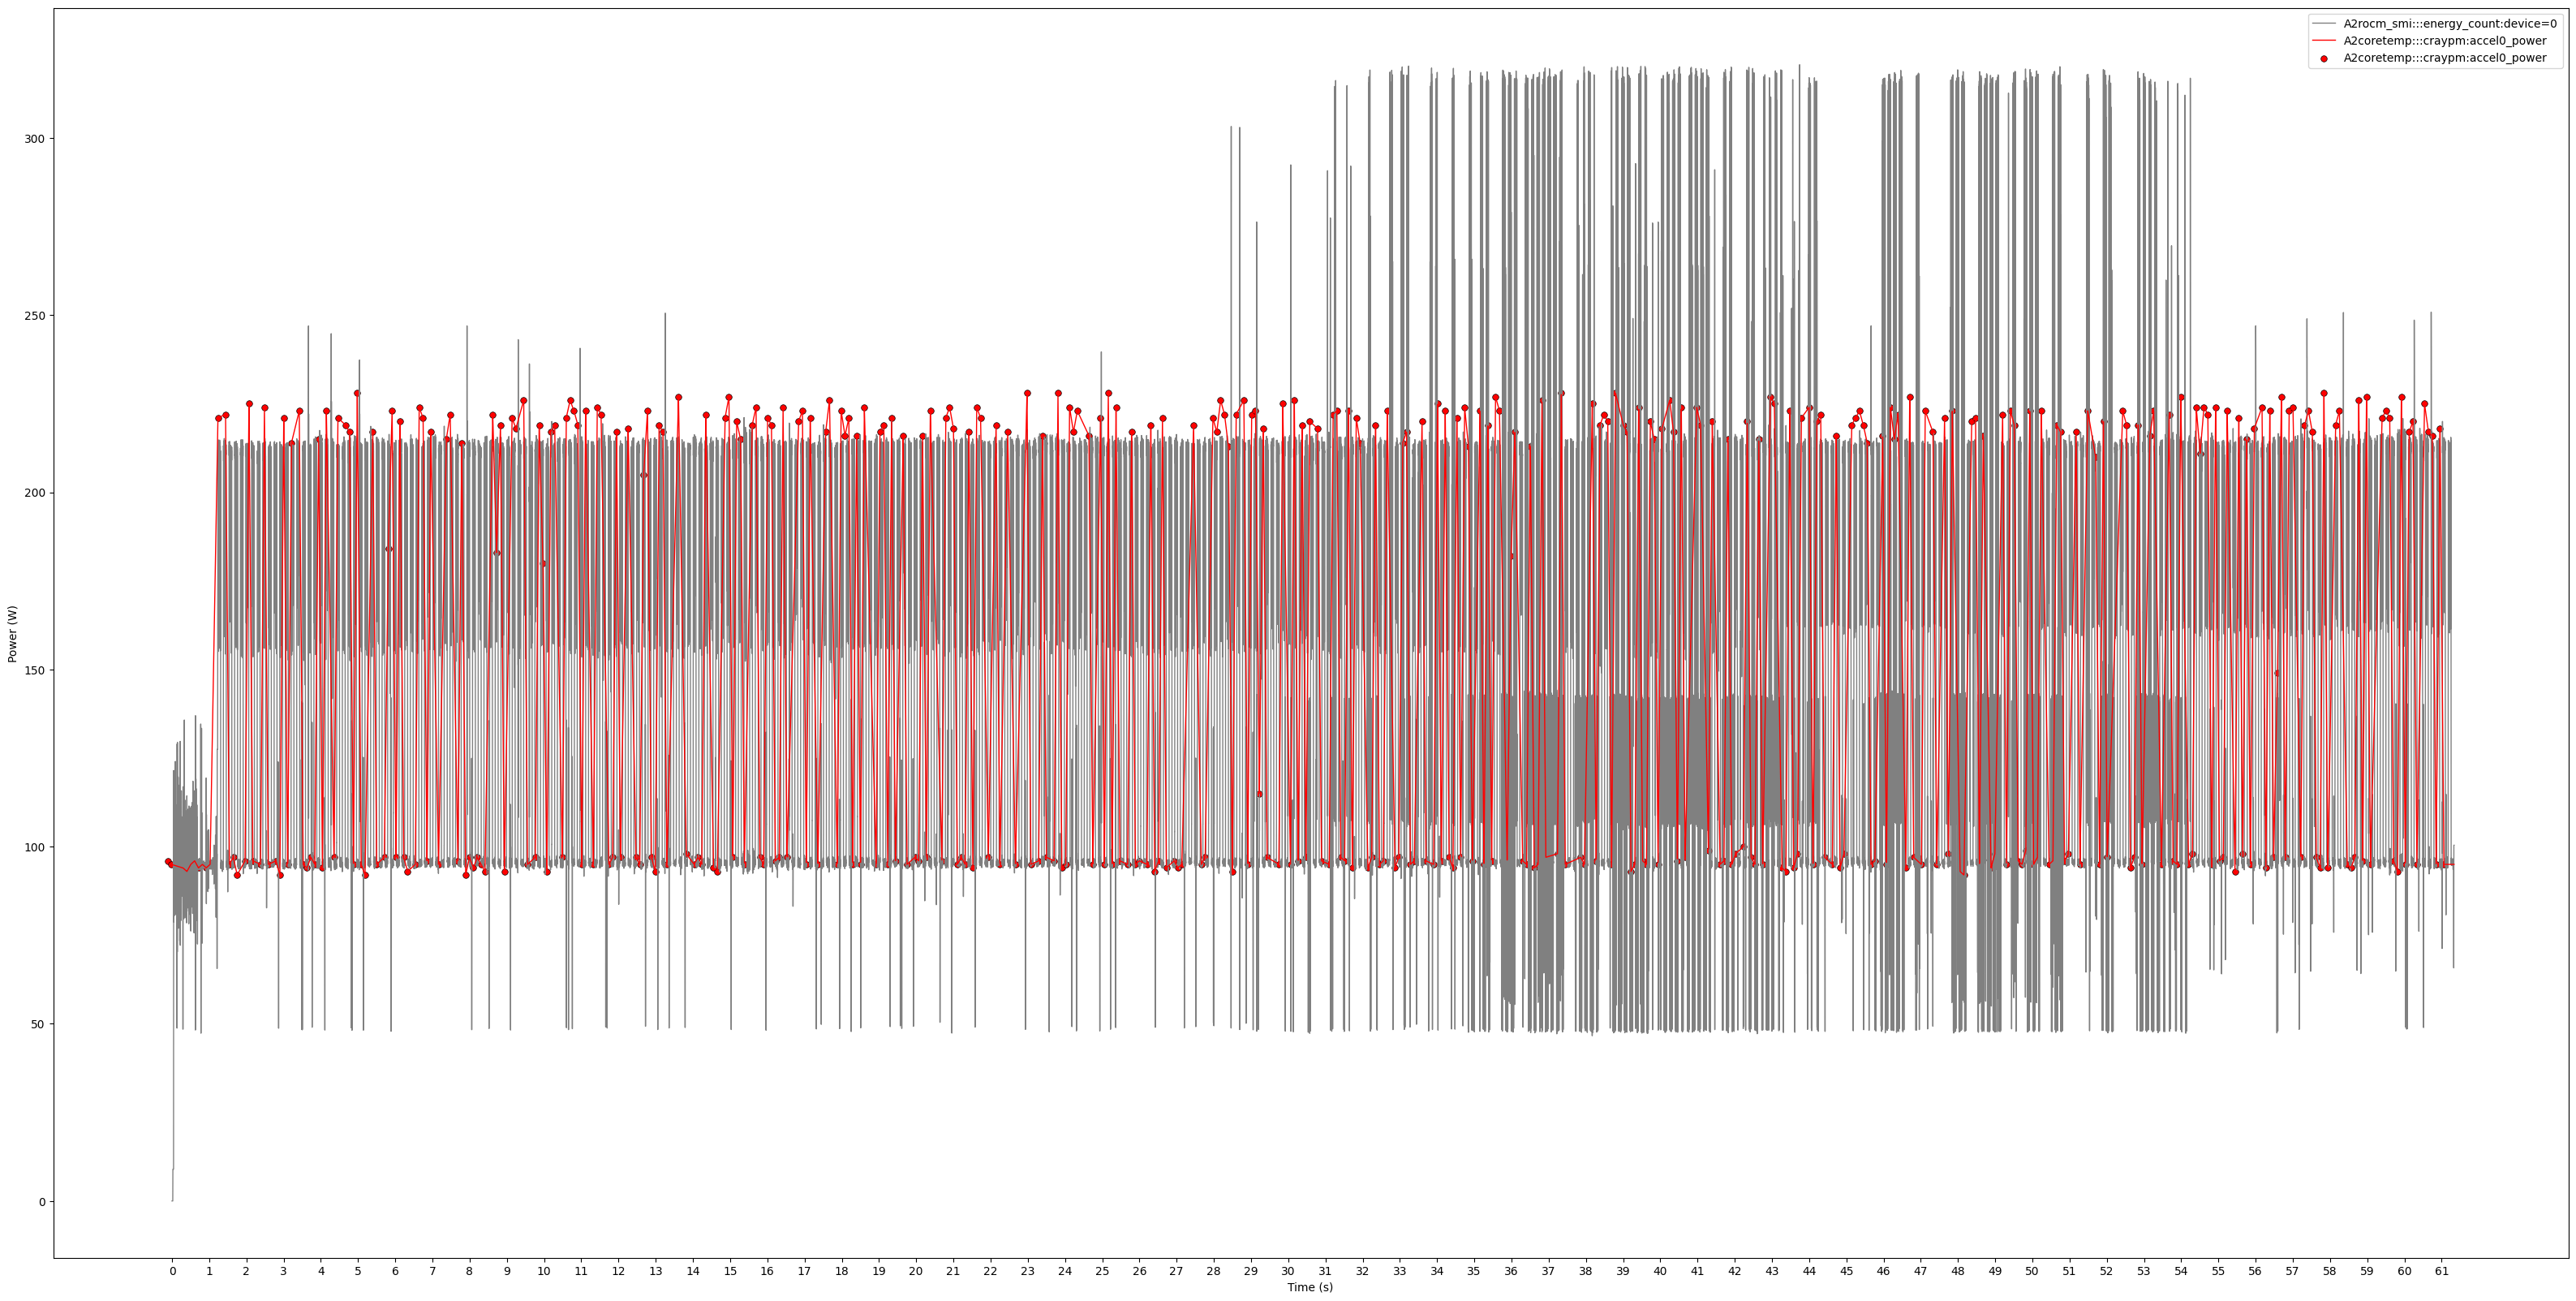

In [12]:
# Graph all the metrics for the specific run
run = list(traces.keys())[0]  # Example run, can be changed
# run = (1, 1)  # Example run, can be changed
# run = (1000, 1)  # Example run, can be changed
run = (75, 75)  # Example run, can be changed
# run = (200, 1000)  # Example run, can be changed
# run = (1, 1000)  # Example run, can be changed
# run = (1, 1000)  # Example run, can be changed
print(f"Plotting GPU powers for run {run}")
plt.figure(figsize=(40, 20))
for metric_name, func in gpu_powers_continuous[run].items():
    if '0' not in metric_name:
        continue
    # Get the max time sample from the traces
    max_time = traces[run][0]['Time'].max()
    t = np.arange(0, max_time, 0.001)  # Time vector for plotting
    y = func(t)  # Evaluate the function at the time points
    if 'rocm' in metric_name:
        # Color red
        # y = windowed_average(func, window_period=1)(t) - func(0)
        y = func(t) - func(0)
        plt.plot(t, y, label=metric_name, color='grey', lw=1)
        rocm_sample_times = traces[run][0][traces[run][0]['Metric Name'] == metric_name]['Time'].values
        # for sample_time in rocm_sample_times:
        scatter_x = rocm_sample_times
        scatter_y = windowed_average(func, window_period=1)(scatter_x)
        # plt.scatter(scatter_x, scatter_y, label=metric_name, color='grey', s=10, alpha=0.5, edgecolor='black', linewidth=0.5)
    # elif 'craypm' in metric_name and 'energy' in metric_name:
    #     # Color blue
    #     plt.plot(t, y, label=metric_name, color='blue')
    elif 'craypm' in metric_name and 'power' in metric_name:
        # Color green
        # y = windowed_average(func, window_period=1)(t)
        y = func(t)
        plt.plot(t, y, label=metric_name, color='red', lw=1)
        
        # Get rocm sample times
        cray_pm_sample_times = traces[run][0][traces[run][0]['Metric Name'] == metric_name]['Time'].values
        # for sample_time in cray_pm_sample_times:
        scatter_x = cray_pm_sample_times
        # scatter_y = windowed_average(func, window_period=1)(scatter_x)
        scatter_y = func(scatter_x)
        plt.scatter(scatter_x, scatter_y, label=metric_name, color='red', s=30, edgecolor='black', linewidth=0.5)
        
    # call_graph_df =  traces[run][1]
    # # print(f"Plotting call graph for run {run}")
    # print(call_graph_df)
    # start_times = call_graph_df['Start Time'].values
    # end_times = call_graph_df['End Time'].values
    # for start_time in start_times:
    #     plt.axvline(x=start_time, color='black', linestyle='--', linewidth=0.1, alpha=0.5)
    # for end_time in end_times:
    #     plt.axvline(x=end_time, color='black', linestyle='--', linewidth=0.1, alpha=0.5)

plt.legend()
plt.ylabel('Power (W)')    
plt.xlabel('Time (s)')
plt.xticks(np.arange(0, max_time, 1))  # Set x-ticks every 0.1 seconds
plt.show()

In [13]:
def correlation(f, g, x, method='pearson'):
    """Compute the correlation between two functions."""
    # # Create the x vector for evaluation
    # x = np.array(list(domain))
    # Evaluate the functions at the x vector
    # Use scipy
    f_values = f(x)
    g_values = g(x)
    # First, apply a median filter to smooth the data
    # f_values = medfilt(f_values, kernel_size=11)
    # g_values = medfilt(g_values, kernel_size=11)
    
    print(f"f_values: {f_values}")
    print(f"g_values: {g_values}")
    # Compute the correlation coefficient using scipy.stats.pearsonr
    if method == 'pearson':
        correlation_coefficient, pvalue = pearsonr(f_values, g_values)
        print(f"Pearson correlation coefficient: {correlation_coefficient}, p-value: {pvalue}")
    elif method == 'spearman':
        correlation_coefficient, _ = spearmanr(f_values, g_values)
    elif method == 'kendall':
        correlation_coefficient, _ = kendalltau(f_values, g_values)
    else:
        raise ValueError(f"Unknown correlation method: {method}")
    return correlation_coefficient

def convert_to_heatmap_data(correlation_matrices):
    """Convert the correlation matrices to a DataFrame for heatmap plotting."""
    data = []
    for (idle_period_ms, active_period_ms), corr in correlation_matrices.items():
        data.append({
            'Idle Period (ms)': idle_period_ms,
            'Active Period (ms)': active_period_ms,
            'Value': corr
        })
    return pd.DataFrame(data)

In [14]:
# Now create a heatmap of all the correlations for each run for the GPU power metrics
# This will be a correlation matrix for each run
correlation_matrices = {}
for idle_period_ms, active_period_ms in traces.keys():
    # Get the GPU power metrics for the specific run
    gpu_power_metrics = gpu_powers_continuous[(idle_period_ms, active_period_ms)]
    
    # Get the functions for the GPU power metrics
    rocm = gpu_power_metrics['A2rocm_smi:::energy_count:device=0'] if 'A2rocm_smi:::energy_count:device=0' in gpu_power_metrics else None
    craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_energy'] if 'A2coretemp:::craypm:accel0_energy' in gpu_power_metrics else None
    # craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_power'] if 'A2coretemp:::craypm:accel0_power' in gpu_power_metrics else None
    
    # If both metrics are present, compute the correlation
    if rocm is not None and craypm is not None:
        corr = correlation(windowed_average(rocm), windowed_average(craypm), np.arange(0, traces[(idle_period_ms, active_period_ms)][0]['Time'].max(), 0.1))
        correlation_matrices[(idle_period_ms, active_period_ms)] = corr
    
print(correlation_matrices)

f_values: [ 17.03572273  90.71615338  90.81956744  91.21499956  91.41740203
  90.07532895  91.52376652  92.31501818  91.81880951  92.0420289
  92.02377498  92.15001762  94.78633106 171.94361985 174.0821898
 172.69484699 174.30463433 173.76317084 173.8076061  174.06564951
 173.67808521 173.69499803 174.31589961 173.60134423 173.69933426
 173.45929146 173.15492034 174.24279451 172.90152609 173.25732112
 174.15007949 173.24903607 174.23592508 172.97817767 173.40426147
 174.28594828 173.41911793 173.86840284 172.09178209 173.71478677
 173.40984941 174.61207509 174.3491888  173.51458967 174.69891906
 174.25528169 173.40186238 174.51916635 174.45512116 173.60952497
 174.52180386 174.57039654 171.45481706 171.4656651  171.91307247
 169.99766231 171.57883942 173.70292544 173.53455722 174.06405509
 173.51993918 174.44905639 174.81055856 174.03559387 174.01005328
 174.69844222 174.2143929  174.22878742 174.69877005 174.30409789
 174.4851321  174.80690777 174.29986596 174.24213886 174.75964129
 1

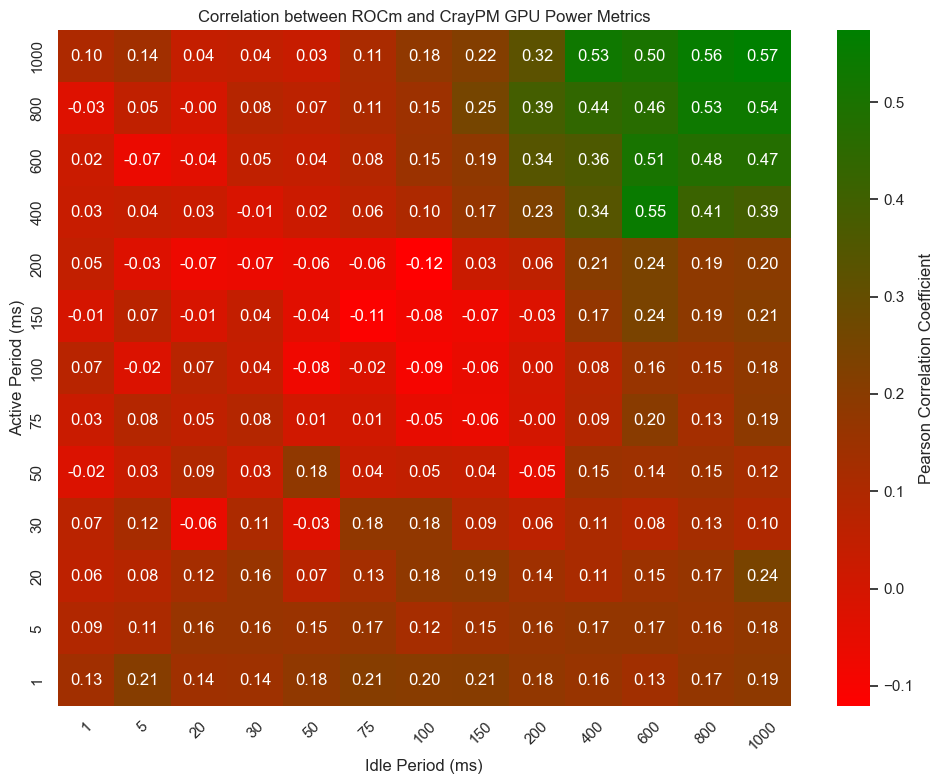

In [15]:
# Graph with SNS matrix
sns.set(style="whitegrid")

# Plot the heatmap
plt.figure(figsize=(10, 8))

# Use idle period as x-axis and active period as y-axis
heatmap_data = convert_to_heatmap_data(correlation_matrices)
heatmap_data_pivot = heatmap_data.pivot(index="Idle Period (ms)", columns="Active Period (ms)", values= "Value")
# Flip the y axis to have the smallest idle period at the top
heatmap_data_pivot = heatmap_data_pivot.sort_index(ascending=False)
cmap = LinearSegmentedColormap.from_list("rojo_verde", ["red", "green"], N=256)
sns.heatmap(heatmap_data_pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": "Pearson Correlation Coefficient"})

plt.title('Correlation between ROCm and CrayPM GPU Power Metrics')
plt.xlabel('Idle Period (ms)')
plt.ylabel('Active Period (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Model to convert rocm power to craypm power
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error


# Now create a heatmap of all the correlations for each run for the GPU power metrics
# This will be a correlation matrix for each run
correlation_matrices = {}
shown = 0
for idle_period_ms, active_period_ms in traces.keys():
    # Get the GPU power metrics for the specific run
    gpu_power_metrics = gpu_powers_continuous[(idle_period_ms, active_period_ms)]
    
    # Get the functions for the GPU power metrics
    rocm = gpu_power_metrics['A2rocm_smi:::energy_count:device=0'] if 'A2rocm_smi:::energy_count:device=0' in gpu_power_metrics else None
    # craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_energy'] if 'A2coretemp:::craypm:accel0_energy' in gpu_power_metrics else None
    craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_power'] if 'A2coretemp:::craypm:accel0_power' in gpu_power_metrics else None
    
    # Get the max and min time samples from the traces
    max_time = traces[(idle_period_ms, active_period_ms)][0]['Time'].max()
    min_time = traces[(idle_period_ms, active_period_ms)][0]['Time'].min()
    
    # If both metrics are present, compute the correlation
    if rocm is not None and craypm is not None:
        t = np.arange(min_time, max_time, 0.001)
        
        y_rocm = rocm(t)
        y_craypm = craypm(t)
        # print(f"Average absolute error for ROCm and CrayPM power metrics for idle {idle_period_ms} ms, active {active_period_ms} ms: {y_avg_absolute_error}")

        loss = mean_absolute_error(y_craypm, y_rocm)

        correlation_matrices[(idle_period_ms, active_period_ms)] = loss
        # if shown < 5:
        #     plt.figure(figsize=(10, 5))
        #     plt.plot(t, y_rocm, label='ROCm Energy', color='red')
        #     plt.plot(t, y_craypm, label='CrayPM Power', color='blue')
            
        #     plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        #     plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
        #     plt.title(f'ROCm Energy vs CrayPM Power for Idle {idle_period_ms} ms, Active {active_period_ms} ms (correlation: {corr:.2f})')
        #     plt.xlabel('Time (s)')
        #     plt.ylabel('Value')
        #     plt.legend()
        #     plt.show()
        # shown += 1
    
print(correlation_matrices)

{(1, 1): 45.26927199514654, (1, 5): 36.30539539752492, (1, 20): 33.35878273840424, (1, 30): 26.429605352694836, (1, 50): 26.44433106839183, (1, 75): 25.76280169910911, (1, 100): 27.428344346302932, (1, 150): 21.939925337696014, (1, 200): 21.81906144771535, (1, 400): 24.108347153651714, (1, 600): 26.423912901839, (1, 800): 24.654828720334713, (1, 1000): 25.487878749966814, (5, 1): 57.607528223371006, (5, 5): 58.649362454938526, (5, 20): 47.18973233145619, (5, 30): 42.82168446214672, (5, 50): 38.138606187201916, (5, 75): 33.65067718511438, (5, 100): 32.17452759436493, (5, 150): 32.60837047510066, (5, 200): 28.168067596114728, (5, 400): 25.72400034058941, (5, 600): 25.80416462985562, (5, 800): 26.47315814997405, (5, 1000): 25.97982051346629, (20, 1): 37.08993193345802, (20, 5): 49.6679321821489, (20, 20): 59.02712941287168, (20, 30): 61.04660857768607, (20, 50): 51.82087070935551, (20, 75): 50.14067940680714, (20, 100): 45.1799546256564, (20, 150): 43.243005636168334, (20, 200): 37.428808

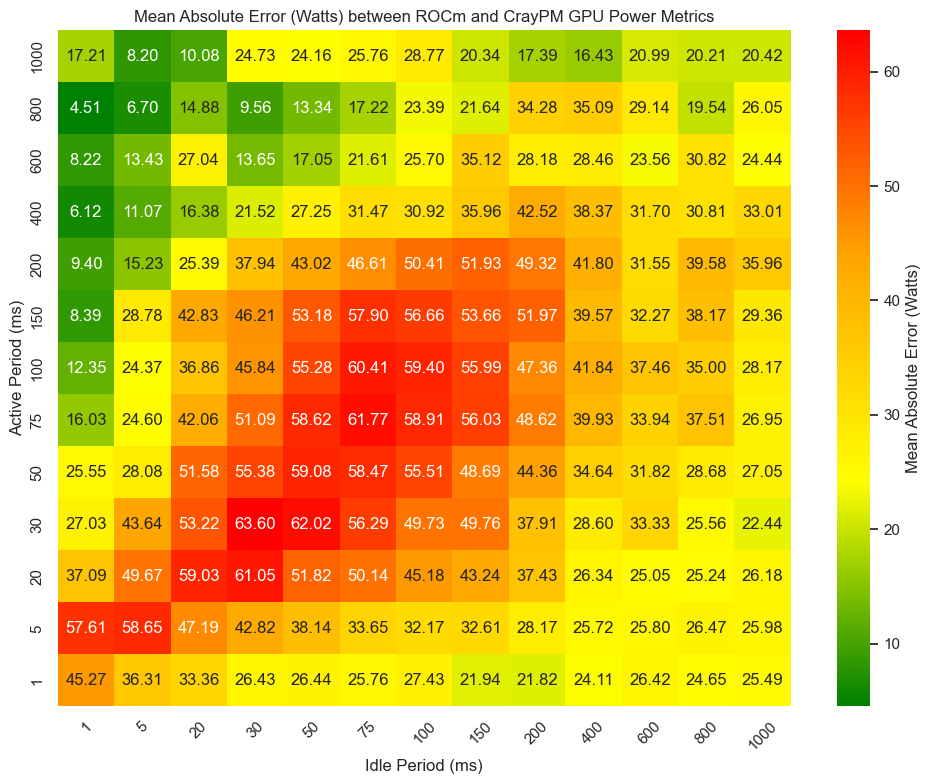

In [17]:
# Graph with SNS matrix
sns.set(style="whitegrid")

# Plot the heatmap
plt.figure(figsize=(10, 8))

# Use idle period as x-axis and active period as y-axis
heatmap_data = convert_to_heatmap_data(correlation_matrices)
heatmap_data_pivot = heatmap_data.pivot(index="Idle Period (ms)", columns="Active Period (ms)", values= "Value")
# Flip the y axis to have the smallest idle period at the top
heatmap_data_pivot = heatmap_data_pivot.sort_index(ascending=False)
# Choose a colormap where lower is red and higher is green
# # cmap = sns.diverging_palette(220, 20, as_cmap=True)
# # cmap = "RdYlGn"
# # cmap = LinearSegmentedColormap.from_list("rojo_verde", ["red", "green"], N=256)
# cmap = LinearSegmentedColormap.from_list("rojo_verde", ["green", "red"], N=64)
# Make it more stark
cmap = LinearSegmentedColormap.from_list("rojo_verde", ["green", "yellow", "orange", "red"], N=256)




sns.heatmap(heatmap_data_pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": "Mean Absolute Error (Watts)"})

plt.title('Mean Absolute Error (Watts) between ROCm and CrayPM GPU Power Metrics')
plt.xlabel('Idle Period (ms)')
plt.ylabel('Active Period (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Model to convert rocm power to craypm power
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error


# Now create a heatmap of all the correlations for each run for the GPU power metrics
# This will be a correlation matrix for each run
correlation_matrices = {}
shown = 0
for idle_period_ms, active_period_ms in traces.keys():
    # Get the GPU power metrics for the specific run
    gpu_power_metrics = gpu_powers_continuous[(idle_period_ms, active_period_ms)]
    
    # Get the functions for the GPU power metrics
    rocm = gpu_power_metrics['A2rocm_smi:::energy_count:device=0'] if 'A2rocm_smi:::energy_count:device=0' in gpu_power_metrics else None
    # craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_energy'] if 'A2coretemp:::craypm:accel0_energy' in gpu_power_metrics else None
    craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_power'] if 'A2coretemp:::craypm:accel0_power' in gpu_power_metrics else None
    
    # Get the max and min time samples from the traces
    max_time = traces[(idle_period_ms, active_period_ms)][0]['Time'].max()
    min_time = traces[(idle_period_ms, active_period_ms)][0]['Time'].min()
    
    # If both metrics are present, compute the correlation
    if rocm is not None and craypm is not None:
        t = np.arange(min_time, max_time, 0.001)
        
        y_rocm = rocm(t)
        y_craypm = craypm(t)
        # print(f"Average absolute error for ROCm and CrayPM power metrics for idle {idle_period_ms} ms, active {active_period_ms} ms: {y_avg_absolute_error}")

        corr = correlation(windowed_average(rocm, 0.4), windowed_average(craypm, 0.4), np.arange(0, traces[(idle_period_ms, active_period_ms)][0]['Time'].max(), 0.1))

        correlation_matrices[(idle_period_ms, active_period_ms)] = corr
    
print(correlation_matrices)

f_values: [ 38.37472945  61.09882891  83.81471783  90.92013165  90.99346772
  91.15490317  91.43788368  91.68401733  91.87011793  92.00195968
  91.8344222  102.54531726 122.84136191 143.24064925 163.83810341
 173.5968478  173.89572784 173.87596145 173.88148606 173.93462732
 173.77245426 173.85135591 173.95856604 173.8416329  173.68764803
 173.72961342 173.44616354 173.42988029 173.30637202 173.418127
 173.66864532 173.44812676 173.71537164 173.40679094 173.53600264
 173.68930578 173.45991731 173.3000949  173.28824103 173.55106026
 173.73428866 174.21941832 174.20135811 174.01024699 174.27700758
 174.18855056 173.95687103 174.22752082 174.22893643 174.01491478
 173.97650704 173.27134311 172.52581939 171.97795957 171.37014493
 171.4069061  172.10448161 172.58886993 173.30980301 173.95408452
 173.9413105  174.24284667 174.43627864 174.243249   174.25652966
 174.38933626 174.27809164 174.38931391 174.5605357  174.40855131
 174.48716611 174.59953576 174.38845709 174.38846827 174.47980866
 1

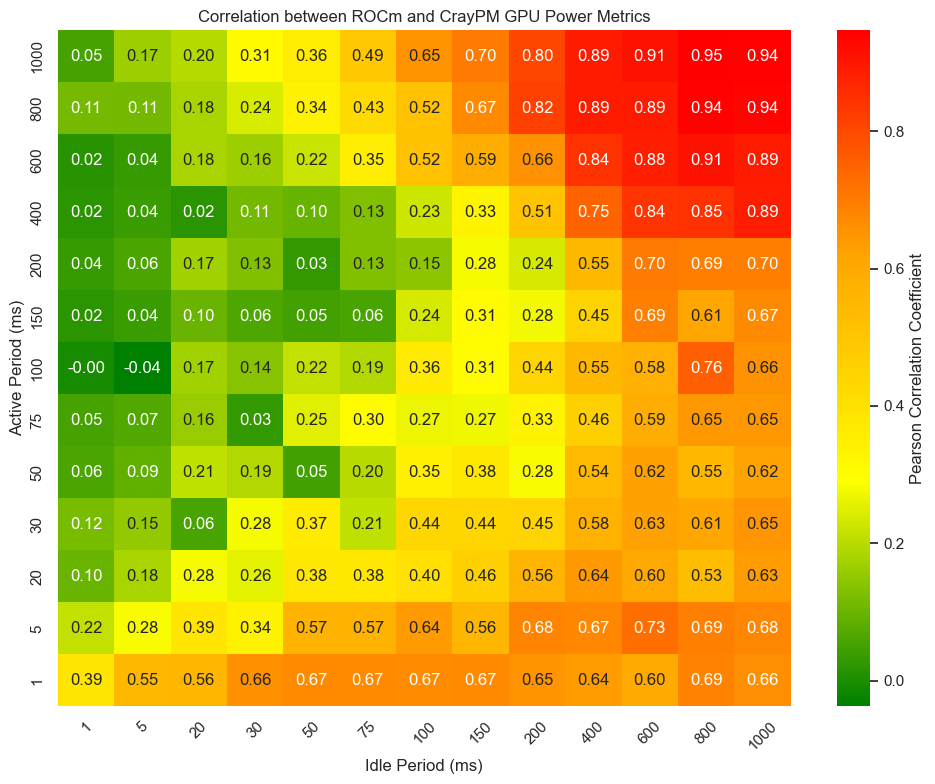

In [19]:
# Graph with SNS matrix
sns.set(style="whitegrid")

# Plot the heatmap
plt.figure(figsize=(10, 8))

# Use idle period as x-axis and active period as y-axis
heatmap_data = convert_to_heatmap_data(correlation_matrices)
heatmap_data_pivot = heatmap_data.pivot(index="Idle Period (ms)", columns="Active Period (ms)", values="Value")
# Flip the y axis to have the smallest idle period at the top
heatmap_data_pivot = heatmap_data_pivot.sort_index(ascending=False)
# Choose a colormap where lower is red and higher is green
# # cmap = sns.diverging_palette(220, 20, as_cmap=True)
# # cmap = "RdYlGn"
# # cmap = LinearSegmentedColormap.from_list("rojo_verde", ["red", "green"], N=256)
# cmap = LinearSegmentedColormap.from_list("rojo_verde", ["green", "red"], N=64)
# Make it more stark
cmap = LinearSegmentedColormap.from_list("rojo_verde", ["green", "yellow", "orange", "red"], N=256)




sns.heatmap(heatmap_data_pivot, annot=True, fmt=".2f", cmap=cmap, cbar_kws={"label": "Pearson Correlation Coefficient"})

plt.title('Correlation between ROCm and CrayPM GPU Power Metrics')
plt.xlabel('Idle Period (ms)')
plt.ylabel('Active Period (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Now create a heatmap of all the correlations for each run for the GPU power metrics
# This will be a correlation matrix for each run
correlation_matrices = {}
for idle_period_ms, active_period_ms in traces.keys():
    # Get the GPU power metrics for the specific run
    gpu_energy_metrics = gpu_energies_continuous[(idle_period_ms, active_period_ms)]
    
    # Get the functions for the GPU power metrics
    rocm = gpu_energy_metrics['A2rocm_smi:::energy_count:device=0'] if 'A2rocm_smi:::energy_count:device=0' in gpu_energy_metrics else None
    craypm = gpu_energy_metrics['A2coretemp:::craypm:accel0_energy'] if 'A2coretemp:::craypm:accel0_energy' in gpu_energy_metrics else None
    # craypm = gpu_power_metrics['A2coretemp:::craypm:accel0_power'] if 'A2coretemp:::craypm:accel0_power' in gpu_power_metrics else None
    
    # If both metrics are present, compute the correlation
    if rocm is not None and craypm is not None:
        corr = correlation(rocm, craypm, np.arange(0, traces[(idle_period_ms, active_period_ms)][0]['Time'].max(), 0.001), method='pearson')
        correlation_matrices[(idle_period_ms, active_period_ms)] = corr
    
print(correlation_matrices)

f_values: [2.60852558e+08 2.60852558e+08 2.60852558e+08 ... 2.60863165e+08
 2.60863165e+08 2.60863165e+08]
g_values: [   87.70635526    87.7353676     87.76437994 ... 11412.
 11412.         11412.        ]
Pearson correlation coefficient: 0.9999360063652576, p-value: 0.0
f_values: [6.63875827e+08 6.63875827e+08 6.63875827e+08 ... 6.63887198e+08
 6.63887198e+08 6.63887198e+08]
g_values: [   44.10377172    44.14648492    44.18919812 ... 12071.
 12071.         12071.        ]
Pearson correlation coefficient: 0.9998562481049622, p-value: 0.0
f_values: [1.76441357e+08 1.76441357e+08 1.76441357e+08 ... 1.76452997e+08
 1.76452997e+08 1.76452997e+08]
g_values: [   51.5482773     51.64418252    51.74008774 ... 12236.
 12236.         12236.        ]
Pearson correlation coefficient: 0.9999756757570745, p-value: 0.0
f_values: [1.76454988e+08 1.76454988e+08 1.76454988e+08 ... 1.76466910e+08
 1.76466910e+08 1.76466910e+08]
g_values: [   41.23547063    41.44895184    41.66243305 ... 12742.
 12742.   

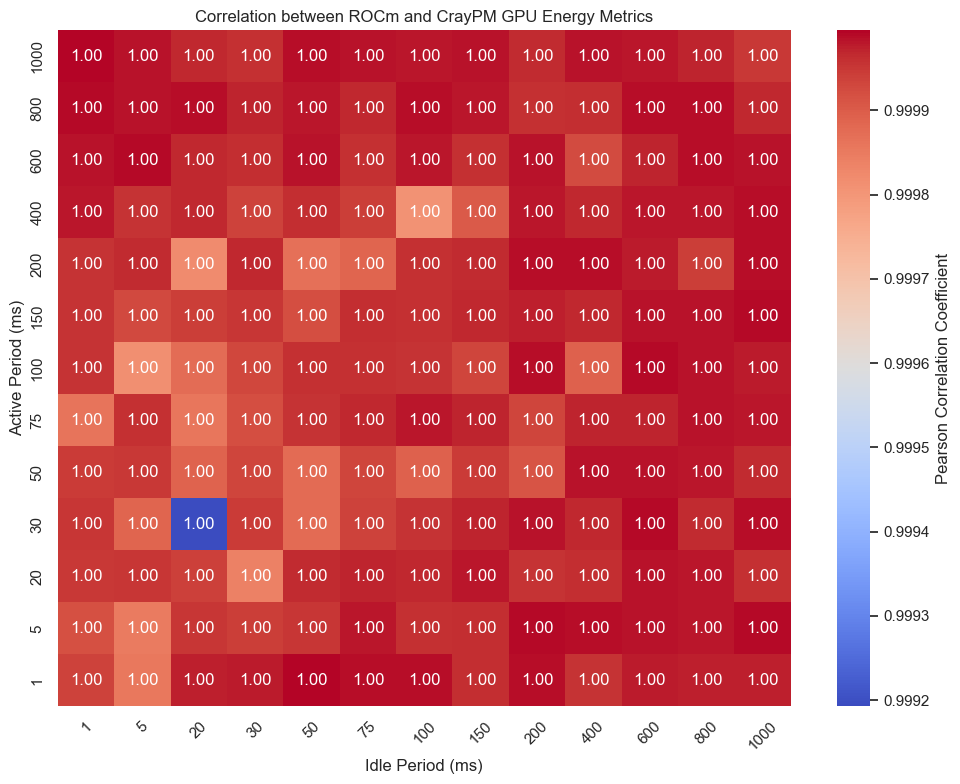

In [21]:
# Graph with SNS matrix
sns.set(style="whitegrid")

# Plot the heatmap
plt.figure(figsize=(10, 8))

# Use idle period as x-axis and active period as y-axis
heatmap_data = convert_to_heatmap_data(correlation_matrices)
heatmap_data_pivot = heatmap_data.pivot(index="Idle Period (ms)", columns="Active Period (ms)", values="Value")
# Flip the y axis to have the smallest idle period at the top
heatmap_data_pivot = heatmap_data_pivot.sort_index(ascending=False)
sns.heatmap(heatmap_data_pivot, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Pearson Correlation Coefficient"})

plt.title('Correlation between ROCm and CrayPM GPU Energy Metrics')
plt.xlabel('Idle Period (ms)')
plt.ylabel('Active Period (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()